This notebook was created and executed via Google Colab, these are the versions for the required libraries:

Scikit-learn: 1.6.1

Pandas: 2.2.2

Numpy: 2.0.2

Matplotlib: 3.10.0

Seaborn: 0.13.2

Scipy: 1.16.3

# Notebook Workflow:

1.   Dataset Upload

2.   Dataset Exploration

3.   Clustering Task

4.   Classification Task

5.   Regression Task

# 1. Dataset Upload

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/diego-rossi-01/BigDataAnalytics-TextMining/refs/heads/main/dataset/e-shop%20clothing%202008.csv"
df = pd.read_csv(url, sep = ";")
print(df.head())

   year  month  day  order  country  session ID  page 1 (main category)  \
0  2008      4    1      1       29           1                       1   
1  2008      4    1      2       29           1                       1   
2  2008      4    1      3       29           1                       2   
3  2008      4    1      4       29           1                       2   
4  2008      4    1      5       29           1                       2   

  page 2 (clothing model)  colour  location  model photography  price  \
0                     A13       1         5                  1     28   
1                     A16       1         6                  1     33   
2                      B4      10         2                  1     52   
3                     B17       6         6                  2     38   
4                      B8       4         3                  2     52   

   price 2  page  
0        2     1  
1        2     1  
2        1     1  
3        2     1  
4        1     

This dataset contains information on clickstream from an online store offering clothing for pregnant women.
All columns for the dataset contain numerical values, except the 'page 2 (clothing model)' column. This column describes the clothing model by assigning a code for each sub-category of product. To exploit this type of information in the analysis, an encoding is produced for this feature.

In [2]:
import numpy as np
import pandas as pd

col = 'page 2 (clothing model)'
s = df[col]

uniques = s.dropna().unique()
assert len(uniques) == 217, f"Trovati {len(uniques)} valori unici (mi aspettavo 217)"

mapping = {val: i for i, val in enumerate(uniques)}
codes = s.map(mapping).to_numpy().astype(int)
uniques_np = np.array(uniques, dtype=object)

print("shape codes:", codes.shape)
print("n_unique (uniques_np):", uniques_np.shape[0])

df['page 2 (clothing model)'] = codes

shape codes: (165474,)
n_unique (uniques_np): 217


# 2. Dataset Exploration

In [3]:
print(f'Dataset size: ', df.shape, '\n')
print(f'Column types: \n', df.dtypes, '\n')

Dataset size:  (165474, 14) 

Column types: 
 year                       int64
month                      int64
day                        int64
order                      int64
country                    int64
session ID                 int64
page 1 (main category)     int64
page 2 (clothing model)    int64
colour                     int64
location                   int64
model photography          int64
price                      int64
price 2                    int64
page                       int64
dtype: object 



In [4]:
df.describe()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
count,165474.0,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000
mean,2008.0,5.585887,14.524554,9.817476,26.952621,12058.417056,2.400842,81.960344,6.227655,3.258198,1.260071,43.802507,1.488167,1.710166
std,0.0,1.328160,8.830374,13.478411,7.150691,7008.418903,1.144420,55.414158,4.235606,1.713206,0.438674,12.548131,0.499861,0.982412
min,2008.0,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000
25%,2008.0,4.000000,7.000000,2.000000,29.000000,5931.000000,1.000000,38.000000,3.000000,2.000000,1.000000,33.000000,1.000000,1.000000
50%,2008.0,5.000000,14.000000,6.000000,29.000000,11967.500000,2.000000,75.000000,4.000000,3.000000,1.000000,43.000000,1.000000,1.000000
75%,2008.0,7.000000,22.000000,12.000000,29.000000,18219.000000,3.000000,126.000000,9.000000,5.000000,2.000000,52.000000,2.000000,2.000000
max,2008.0,8.000000,31.000000,195.000000,47.000000,24026.000000,4.000000,216.000000,14.000000,6.000000,2.000000,82.000000,2.000000,5.000000


This dataset doesn't contain null values, hence methods to handle NAs are not employed.

# 3. CLUSTERING TASK

In [5]:
df.columns

Index(['year', 'month', 'day', 'order', 'country', 'session ID',
       'page 1 (main category)', 'page 2 (clothing model)', 'colour',
       'location', 'model photography', 'price', 'price 2', 'page'],
      dtype='object')

To have better performance for the clustering task, analysis are conducted on sessions performed by the same user, and not on single rows of the original clickstream dataset. The following code cell exploits the original data to create new columns while grouping the data by session id.

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore")


session_col = 'session ID'

df_sorted = df.sort_values([session_col, 'order'])

# =========================
# 1. Base Aggregations
# =========================

base_agg = df.groupby(session_col).agg(
    num_categories=('page 1 (main category)', 'nunique'),
    num_products=('page 2 (clothing model)', 'nunique'),
    session_length=('order', 'count'),
    num_pages=('page', 'nunique'),
    min_price=('price', 'min'),
    max_price=('price', 'max'),
    mean_price=('price', 'mean'),
    std_price=('price', 'std')
)

base_agg['std_price'] = base_agg['std_price'].fillna(0)
base_agg['price_range'] = base_agg['max_price'] - base_agg['min_price']
base_agg['price_cv'] = (
    base_agg['std_price'] / base_agg['mean_price'].replace(0, np.nan)
).fillna(0)

base_agg['product_category_ratio'] = (
    base_agg['num_products'] / base_agg['num_categories'].replace(0, np.nan)
).fillna(0)

# =========================
# 2. Advanced Features
# =========================

def advanced_features(x):
    x = x.sort_values('order')
    n = len(x)

    # Dominant category ratio
    dom_ratio = x['page 1 (main category)'].value_counts(normalize=True).iloc[0]

    # Location entropy
    p_loc = x['location'].value_counts(normalize=True)
    loc_entropy = -(p_loc * np.log2(p_loc)).sum()

    # Category gini
    p_cat = x['page 1 (main category)'].value_counts(normalize=True)
    cat_gini = 1 - (p_cat**2).sum()

    # Avg price last half
    avg_price_late = x.iloc[n//2:]['price'].mean()

    # Price delta
    price_delta = x['price'].iloc[-1] - x['price'].iloc[0] if n > 1 else 0

    # Price trend
    if n > 1:
        t = np.arange(n)
        slope, _, _, _, _ = linregress(t, x['price'].values)
    else:
        slope = 0

    # Category switches
    cat_switch = (x['page 1 (main category)'] !=
                  x['page 1 (main category)'].shift()).sum() - 1

    # Clicks per page
    clicks_per_page = n / x['page'].nunique()

    return pd.Series({
        'dominant_cat_ratio': dom_ratio,
        'location_entropy': loc_entropy,
        'category_gini': cat_gini,
        'avg_price_late': avg_price_late,
        'price_delta': price_delta,
        'price_trend': slope,
        'category_switch_count': cat_switch,
        'clicks_per_page': clicks_per_page
    })

advanced_agg = df.groupby(session_col).apply(advanced_features)

# =========================
# 3. Aggregate Embeddings
# =========================

embedding_cols = [c for c in df.columns if 'emb_' in c]

if len(embedding_cols) > 0:
    emb_mean = df.groupby(session_col)[embedding_cols].mean()
    emb_var = (
        df.groupby(session_col)[embedding_cols]
        .var()
        .fillna(0)
        .add_suffix('_var')
    )
    embedding_agg = pd.concat([emb_mean, emb_var], axis=1)
else:
    embedding_agg = pd.DataFrame(index=base_agg.index)

# =========================
# 4. New Dataset Implementation
# =========================

df_session = (
    base_agg
    .join(advanced_agg)
    .join(embedding_agg)
    .fillna(0)
)

print("df_session shape:", df_session.shape)
df_session.head()

df_session shape: (24026, 19)


,num_categories,num_products,session_length,num_pages,min_price,max_price,mean_price,std_price,price_range,price_cv,product_category_ratio,dominant_cat_ratio,location_entropy,category_gini,avg_price_late,price_delta,price_trend,category_switch_count,clicks_per_page
session ID,,,,,,,,,,,,,,,,,,,
1,4,9,9,3,28,57,42.111111,10.313152,29,0.244903,2.250000,0.333333,2.503258,0.740741,45.600000,20.0,1.266667,3.0,3.000000
2,3,8,10,2,38,67,50.000000,10.381608,29,0.207632,2.666667,0.500000,2.521928,0.620000,44.800000,-14.0,-2.145455,3.0,5.000000
3,3,6,6,2,28,48,42.166667,8.010410,20,0.189970,2.000000,0.666667,1.918296,0.500000,39.666667,5.0,0.142857,2.0,3.000000
4,2,4,4,3,33,62,45.250000,12.789970,29,0.282651,2.000000,0.500000,2.000000,0.500000,40.500000,-5.0,-2.900000,1.0,1.333333
5,1,1,1,1,57,57,57.000000,0.000000,0,0.000000,1.000000,1.000000,-0.000000,0.000000,57.000000,0.0,0.000000,0.0,1.000000


In [7]:
from sklearn.preprocessing import StandardScaler
X = df_session.copy()
print(X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(24026, 19)


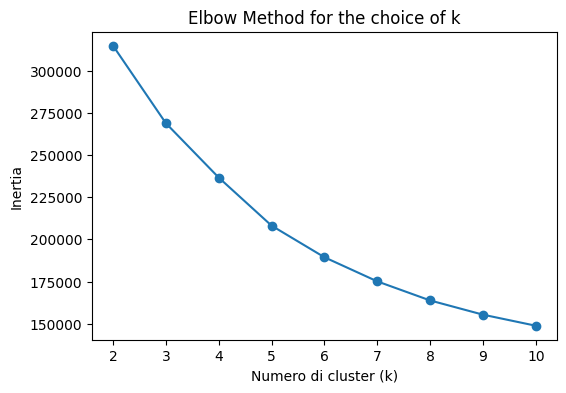

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Numero di cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for the choice of k')
plt.show()

The value chosen for parameter k (number of groups), following the elbow method rule, is 4.

k = 5 could also have been a good choice for the parameter value.

In [9]:
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

df_session['cluster'] = cluster_labels
df_session['cluster'].value_counts().sort_index()

,count
cluster,
0,10447
1,4957
2,5216
3,3406


In [10]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

centroids

,num_categories,num_products,session_length,num_pages,min_price,max_price,mean_price,std_price,price_range,price_cv,product_category_ratio,dominant_cat_ratio,location_entropy,category_gini,avg_price_late,price_delta,price_trend,category_switch_count,clicks_per_page
0,1.857348,5.059032,5.472445,1.962591,32.153655,59.662457,45.134172,12.318377,27.508802,0.273657,3.107611,0.749076,1.548867,0.310669,44.948373,-0.505645,-0.154965,0.977995,3.185122
1,3.176019,16.502624,18.836294,3.242229,25.713969,66.234962,43.310455,12.085824,40.520993,0.279068,5.546780,0.542799,2.228208,0.562111,42.149784,-0.976181,-0.325574,3.133629,6.489843
2,1.108508,1.673132,1.819858,1.220664,34.419819,37.420588,35.930000,1.749743,3.000768,0.049102,1.533481,0.956242,0.406736,0.049583,35.876969,-0.067217,-0.083410,0.118110,1.500896
3,1.045708,1.465573,1.607091,1.121594,55.148550,57.718137,56.478649,1.530521,2.569587,0.027204,1.407999,0.981130,0.310643,0.021117,56.724934,0.460885,0.438321,0.048052,1.430120


In [11]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, df_session['cluster'])
print(round(sil_score, 4))

0.2336


When it comes to clickstream data, both the overlap in PCA visualization and the low Silhouette score of the clusters are explainable.

Silhouette scores between 0.2 and 0.4 aren't considered as optimal but are acceptable when it comes to clickstream data context, as scores that exceed 0.5 are rare.

PC1 clearly separates one cluster (coloured in red in the following representation) with long sessions, more clicks, and wider price ranges.
The other three clusters are mainly separated along PC2 but overlap on PC1, as some clickstream features are correlated and dominate variance.


Despite some visual overlap of clusters, quantitative metrics and centroid analysis show a clear differentiation of session behavior patterns. Moreover, the overlap is expected since PCA does not optimize cluster separation but captures overall variance.

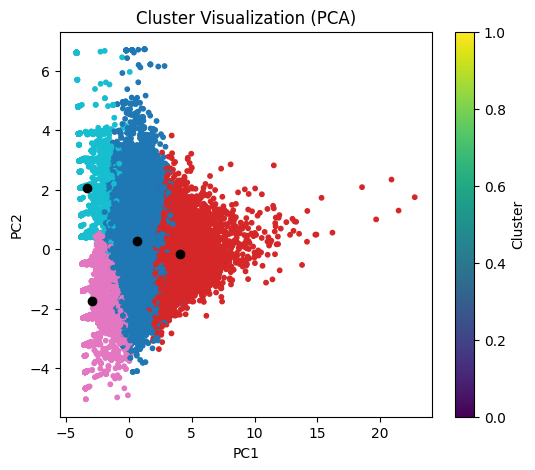

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_session['cluster'],
    cmap='tab10',
    s=10
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='black'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cluster Visualization (PCA)')
plt.colorbar(label='Cluster')
plt.show()

Following the implementation of the K-means algorithm for the clustering task, the identified clusters can be analysed by interpreting the values of each feature for the centroids.
In the data-driven strategic decision making framework, these analysis help organizations (in this case the company that sells clothing) to have a better understanding of the behaviour of the e-commerce website users.

---

**First cluster** (with label 0, represented with colour blue in the PCA visualization):

This cluster is populated by individuals that have medium or short sessions on the website (session_length = 5.47 on average, num_products close to 5 on average), visiting about 2 categories of products (num_categories = 1.86 on average) with a single dominant category of clothing that they focus on (dominant_cat_ratio = 0.75).

The price of the clothing they view has an average of 45 US dollars and a standard deviation of 12. Price trend of the products they view is on average close to -0.15, meaning that these individuals tend to visit pages of cheaper clothes following the first that they've already visited.

If we want to assign a meaningful label to this cluster, we could identify these individuals as curious explorers that visit clothes with a progressive price downgrade, probably searching for occasions and discounts for a particular category of products.

---

**Second cluster** (with label 1, represented with colour red in the PCA visualization):

This cluster identifies users that conduct longer sessions (session_length = 18.8 on average, num_products close to 16.5 on average), visiting about 3.17 categories on average and being particularly active as they often change categories (category_switch_count = 3.13 on average) and have higher clicks_per_page count (close to 6.48 on average).

The average price for the clothes viewed is similar to the one of the first group (mean_price = 43 USD on average) and the price trend is also negative on average, close to -0.32.

The users identified in this cluster can be recognized as dynamic users that are not looking for something in particular but instead visit the shop in search for occasions that they recognize by comparing prices between different products.

---

**Third cluster** (with label 2, represented with colour pink in the PCA visualization):

This cluster groups users that have minimal sessions (session_length = 1.8, num_products = 1.67 on average), visiting in most cases just one or two products in the same category without exploring the rest of the shop (num_categories = 1.1, dominant_cat_ratio = 0.95 on average).

Price of the viewed products is a little lower with respect to the first 2 clusters and very stable (mean_price = 36, std_price = 1.7, price_trend = -0.08 on average).

It is possible to interpret the users in this cluster as focused buyers that are already oriented to the products they want to view and probably have a rapid decisional behaviour too.

---

**Fourth cluster** (with label 3, represented with colour light blue in the PCA visualization):

This last cluster groups the users that also have short sessions (session_length = 1.6, num_products = 1.47 on average) and also visit just one category without switching (num_categories = 1.05, dominant_cat_ratio = 0.98, category_switch_count = 0.05 on average).

The main difference with the third cluster stands in the price, both in levels and trend (mean_price = 56, price_trend = +0.43 on average).  

It is possible to identify these users as focused buyers looking for premium products, as they are probably more interested in the clothes quality than in the price levels or discounts.

# 4. CLASSIFICATION TASK

### BINARY CLASSIFICATION

In the original dataset, the column 'price 2' is defined by the authors as it follows:

PRICE 2 -> variable informing whether the price of a product is higher than
the average price for the entire product category
1-yes
2-no

Therefore this dataset feature in particular was chosen as a target column for binary classification, as price is very appropriate as a dependent variable and these labels already provided by the authors permits to work in the context of supervised classification task.

The column 'price' is obviously removed by the dataset as well as the target column, otherwise every model would have been perfectly performing.

In [17]:
from sklearn.model_selection import train_test_split

target_col = 'price 2'

X = df.drop(columns=[target_col, 'price'])
y = df[target_col]

print(X.shape, y.shape)


(165474, 12) (165474,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

After splitting the dataset in training and testing set, a baseline linear model is implemented. In this case, the linear model chosen was the logistic regression model.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.5698
              precision    recall  f1-score   support

           1       0.58      0.59      0.58     16939
           2       0.56      0.55      0.55     16156

    accuracy                           0.57     33095
   macro avg       0.57      0.57      0.57     33095
weighted avg       0.57      0.57      0.57     33095



The baseline model performs poorly, most likely because logistic regression model is not able to capture non-linear dependency and correlation in the data. Accuracy of classification is below 60%, precisely at 56.98%, even if the two classes do not show imbalances and are both well-represented. Precision and recall are close to 60% as well for both classes, showing the algorithm is more precise when the prices are below average.

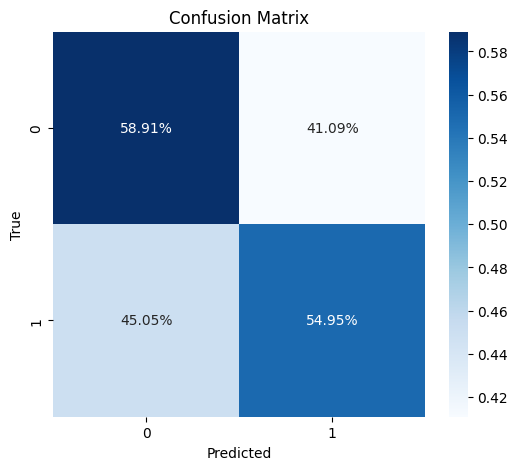

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Confusion Matrix confirms the poor performance of this model as well as the higher precision for below average prices.


Switching to a more complex, non-linear model such as Random Forest Classifier is necessary to have satisfactory results.

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rfc = RandomForestClassifier(
    n_estimators=10,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42
)


rfc.fit(X_train, y_train)

y_pred_rfc = rfc.predict(X_test)
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)

print(f'Accuracy: {accuracy_rfc:.4f}')
print(classification_report(y_test, y_pred_rfc))

Accuracy: 0.9678
              precision    recall  f1-score   support

           1       0.97      0.97      0.97     16939
           2       0.97      0.96      0.97     16156

    accuracy                           0.97     33095
   macro avg       0.97      0.97      0.97     33095
weighted avg       0.97      0.97      0.97     33095



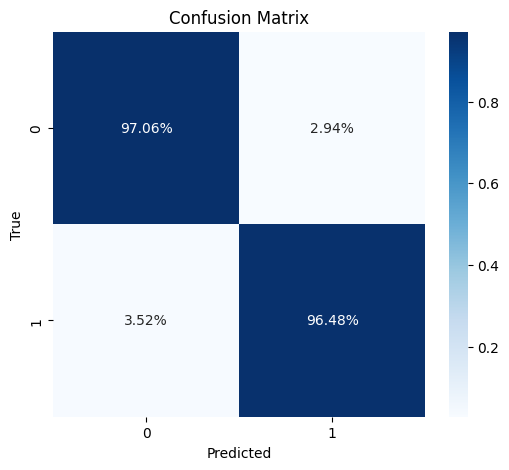

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rfc, normalize='true')
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Implementing the Random Forest Classifier model shows the difference in capturing non-linear correlation and dependency between data, as even a little model (with the number of trees n_estimators set to 10) performs incredibly well in binary classification.

### MULTI-CLASS CLASSIFICATION

It is possible to implement a multi-class supervised classification task too.

In particular, the cluster of belonging for each of the sessions conducted are employed as labels for the classifications and the *df_session* dataset is employed instead of the original one.

Accuracy: 0.9644
Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2090
           1       0.97      0.95      0.96       992
           2       0.99      0.96      0.97      1043
           3       0.99      0.95      0.97       681

    accuracy                           0.96      4806
   macro avg       0.97      0.96      0.97      4806
weighted avg       0.97      0.96      0.96      4806



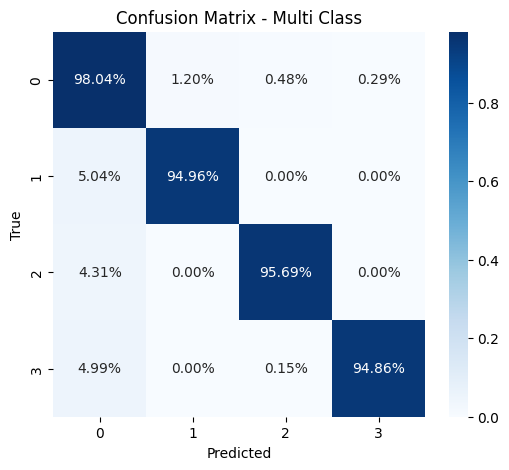

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import RobustScaler
import seaborn as sns
import matplotlib.pyplot as plt

X = df_session.drop(columns=['cluster'])
y = df_session['cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rfc.fit(X_train, y_train) #The same model (rfc) used for binary classification is employed even for this multi-classification task.

y_pred = rfc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Multi Class')
plt.show()

The same Random Forest Classification model is employed for both the binary and multi-class classification tasks, and even in this case the performance is excellent, further demonstrating that the clusters created are appropriate even if the Silhouette score is lower than expected and overlapping shows in the PCA cluster visualization.

# 5. REGRESSION TASK

For the regression task, instead of using the variable 'price 2' that contains labels as the target variable for supervised binary classification, it is sufficient to switch to the 'price' feature, that contains prices expressed in continuous value.

The column 'price 2' is removed from the dataset as well as the target column.

In [24]:
target_col = 'price'

X = df.drop(columns=[target_col, 'price 2'])
y = df[target_col]

print(X.shape, y.shape)

(165474, 12) (165474,)


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The baseline model implemented for regression is obviously the linear regression model.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred = lin_reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R^2  = {r2:.3f}")

MAE  = 9.86
RMSE = 11.51
R^2  = 0.164


As it is noticeable by the previously computed metrics, linear regression has poor performance, in particular with a low score for the R^2 at 16.4%. The model explains only a small portion of the variability in the target variable, with predictions that don't closely follow the actual observed values. It is possible the performance is influenced by the linearity of the model, as it happened already in the case of binary classification.

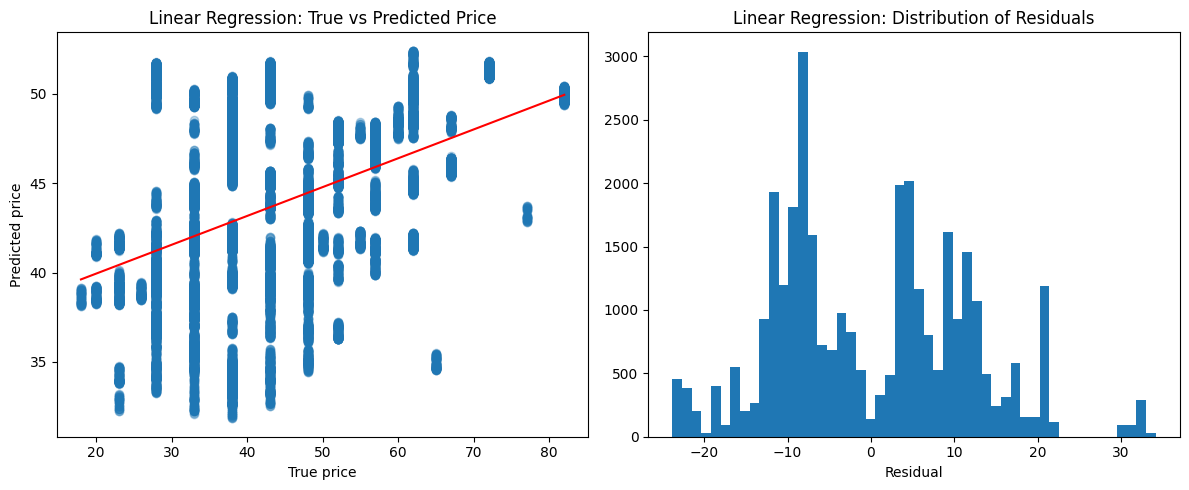

In [27]:
import numpy as np
import matplotlib.pyplot as plt

x_line = np.linspace(y_test.min(), y_test.max(), 100)
m, q = np.polyfit(y_test, y_pred, 1)

y_line = m * x_line + q

residuals = y_test - y_pred


fig, ax = plt.subplots(1, 2, figsize=(12,5))
# --- Grafico 1: True vs Predicted ---
ax[0].scatter(y_test, y_pred, alpha=0.3)
ax[0].plot(x_line, y_line, color='red')
ax[0].set_xlabel('True price')
ax[0].set_ylabel('Predicted price')
ax[0].set_title('Linear Regression: True vs Predicted Price')

# --- Grafico 2: Distribuzione residui ---
ax[1].hist(residuals, bins=50)
ax[1].set_xlabel('Residual')
ax[1].set_title('Linear Regression: Distribution of Residuals')

plt.tight_layout()
plt.show()

Gradient Boosting Regressor is implemented to see if a non-linear model has better performance on the dataset.

In [28]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_scaled, y_train)

y_pred = gbr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R^2  = {r2:.3f}")

MAE  = 4.46
RMSE = 5.63
R^2  = 0.800


The performance is very good, as signaled by the R^2 significant increase.

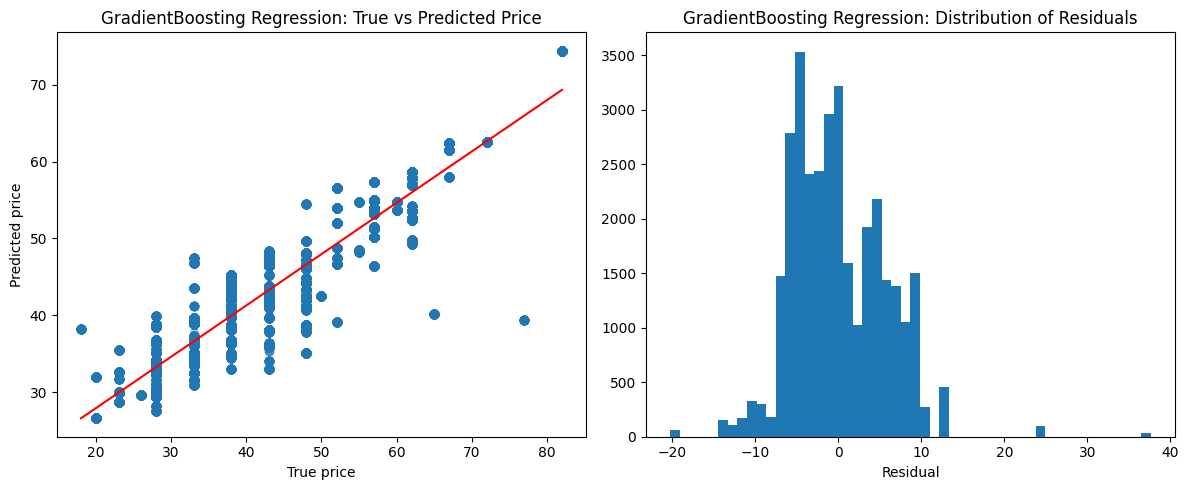

In [30]:
import numpy as np
import matplotlib.pyplot as plt

x_line = np.linspace(y_test.min(), y_test.max(), 100)
m, q = np.polyfit(y_test, y_pred, 1)

y_line = m * x_line + q

residuals = y_test - y_pred


fig, ax = plt.subplots(1, 2, figsize=(12,5))
# --- Grafico 1: True vs Predicted ---
ax[0].scatter(y_test, y_pred, alpha=0.3)
ax[0].plot(x_line, y_line, color='red')
ax[0].set_xlabel('True price')
ax[0].set_ylabel('Predicted price')
ax[0].set_title('GradientBoosting Regression: True vs Predicted Price')

# --- Grafico 2: Distribuzione residui ---
ax[1].hist(residuals, bins=50)
ax[1].set_xlabel('Residual')
ax[1].set_title('GradientBoosting Regression: Distribution of Residuals')

plt.tight_layout()
plt.show()